 2 A

In [1]:
import pandas as pd

data = {
    "existing_column": [45, 65, 30, 75, 90, 55, 70, 25, 85, 40],
    "another_column": [80, 90, 110, 60, 95, 85, 40, 130, 55, 75],
    "category_column": ["A", "B", "C", "A", "B", "C", "A", "B", "C", "A"],
    "numeric_column": [120, 200, 150, 300, 250, 180, 220, 100, 280, 160],
    "column1": [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    "column2": [150, 160, 170, 180, 190, 200, 210, 220, 230, 240]
}

df = pd.DataFrame(data)
df.to_csv("data.csv", index=False)

print("data.csv created successfully.")

data.csv created successfully.


First 5 Rows
   existing_column  another_column category_column  numeric_column  column1  \
0               45              80               A             120       10   
1               65              90               B             200       20   
2               30             110               C             150       30   
3               75              60               A             300       40   
4               90              95               B             250       50   

   column2  
0      150  
1      160  
2      170  
3      180  
4      190  

Last 5 Rows
   existing_column  another_column category_column  numeric_column  column1  \
5               55              85               C             180       60   
6               70              40               A             220       70   
7               25             130               B             100       80   
8               85              55               C             280       90   
9               40        

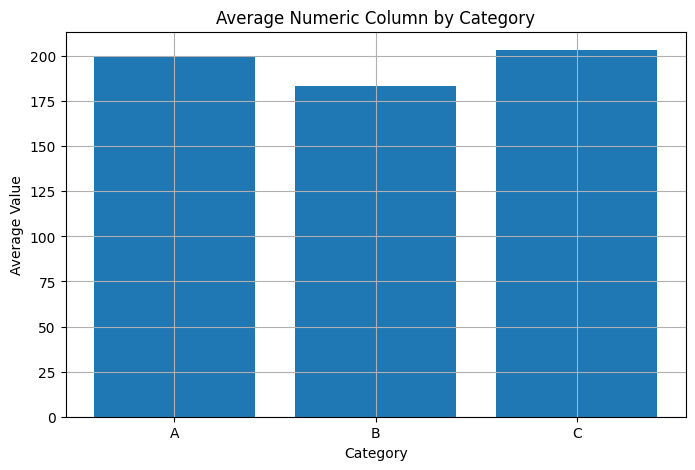

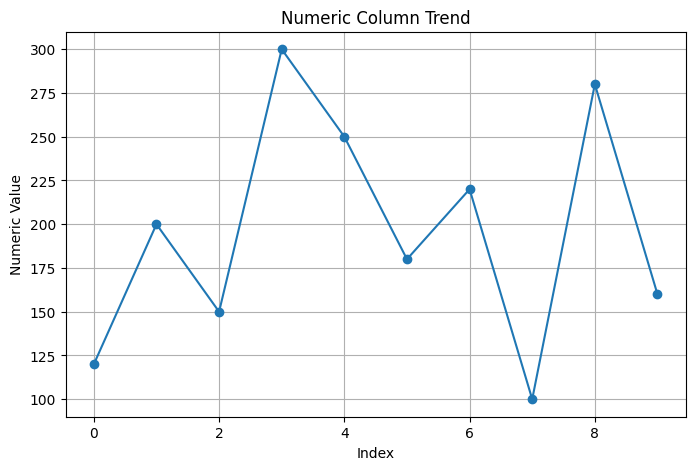

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")

rows = len(df)

required_columns = {
    "existing_column": np.random.randint(1, 100, rows),
    "another_column": np.random.randint(1, 150, rows),
    "category_column": np.random.choice(["A", "B", "C"], rows),
    "numeric_column": np.random.randint(10, 500, rows),
    "column1": np.random.randint(1, 100, rows),
    "column2": np.random.randint(100, 200, rows)
}

for col, values in required_columns.items():
    if col not in df.columns:
        df[col] = values

print("First 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nData Information")
df.info()

print("\nSummary Statistics")
print(df.describe())

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

df["new_column"] = df["existing_column"] * 2

series = df["existing_column"]

print("\nSeries + 10")
print(series + 10)

filtered_df = df[
    (df["existing_column"] > 50) &
    (df["another_column"] < 100)
]

print("\nFiltered DataFrame")
print(filtered_df)

grouped = df.groupby("category_column")["numeric_column"].mean()

print("\nGrouped Mean")
print(grouped)

df_sorted = df.sort_values(by="numeric_column", ascending=False)

print("\nSorted DataFrame")
print(df_sorted)

masked_df = df[df["numeric_column"] > df["numeric_column"].median()]

print("\nMasked DataFrame")
print(masked_df)

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

subset_df = df[["column1", "column2"]]

subset_df.to_csv("filtered_data.csv", index=False)

print("\nTotal Sum:", df["numeric_column"].sum())
print("Mean:", df["numeric_column"].mean())
print("Standard Deviation:", df["numeric_column"].std())

plt.figure(figsize=(8,5))
plt.bar(grouped.index, grouped.values)
plt.title("Average Numeric Column by Category")
plt.xlabel("Category")
plt.ylabel("Average Value")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(df.index, df["numeric_column"], marker="o")
plt.title("Numeric Column Trend")
plt.xlabel("Index")
plt.ylabel("Numeric Value")
plt.grid(True)
plt.show()